In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
data_path = 'Downloads/customer_churn_dataset.csv'
df = pd.read_csv(data_path, encoding='ascii', delimiter=',')
df

,customer_id,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
0,1,52,54.20,2818.40,Month-to-month,Credit,DSL,No,Yes,1,No
1,2,15,35.28,529.20,Month-to-month,Debit,DSL,No,No,2,No
2,3,72,78.24,5633.28,Month-to-month,Debit,DSL,No,No,0,No
3,4,61,80.24,4894.64,One year,Cash,Fiber,Yes,Yes,0,No
4,5,21,39.38,826.98,Month-to-month,UPI,Fiber,No,No,4,Yes
...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,36,69.51,2502.36,Two year,Cash,DSL,No,Yes,0,Yes
19996,19997,10,59.88,598.80,Month-to-month,UPI,Fiber,Yes,No,1,No
19997,19998,6,42.96,257.76,Month-to-month,Credit,Fiber,No,No,2,No
19998,19999,7,102.85,719.95,Month-to-month,Debit,DSL,Yes,No,2,No


In [5]:
print('Initial dataset shape:', df.shape)

Initial dataset shape: (20000, 11)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       20000 non-null  int64  
 1   tenure            20000 non-null  int64  
 2   monthly_charges   20000 non-null  float64
 3   total_charges     20000 non-null  float64
 4   contract          20000 non-null  object 
 5   payment_method    20000 non-null  object 
 6   internet_service  17987 non-null  object 
 7   tech_support      20000 non-null  object 
 8   online_security   20000 non-null  object 
 9   support_calls     20000 non-null  int64  
 10  churn             20000 non-null  object 
dtypes: float64(2), int64(3), object(6)
memory usage: 1.7+ MB


In [9]:
df.isna().sum()

customer_id            0
tenure                 0
monthly_charges        0
total_charges          0
contract               0
payment_method         0
internet_service    2013
tech_support           0
online_security        0
support_calls          0
churn                  0
dtype: int64

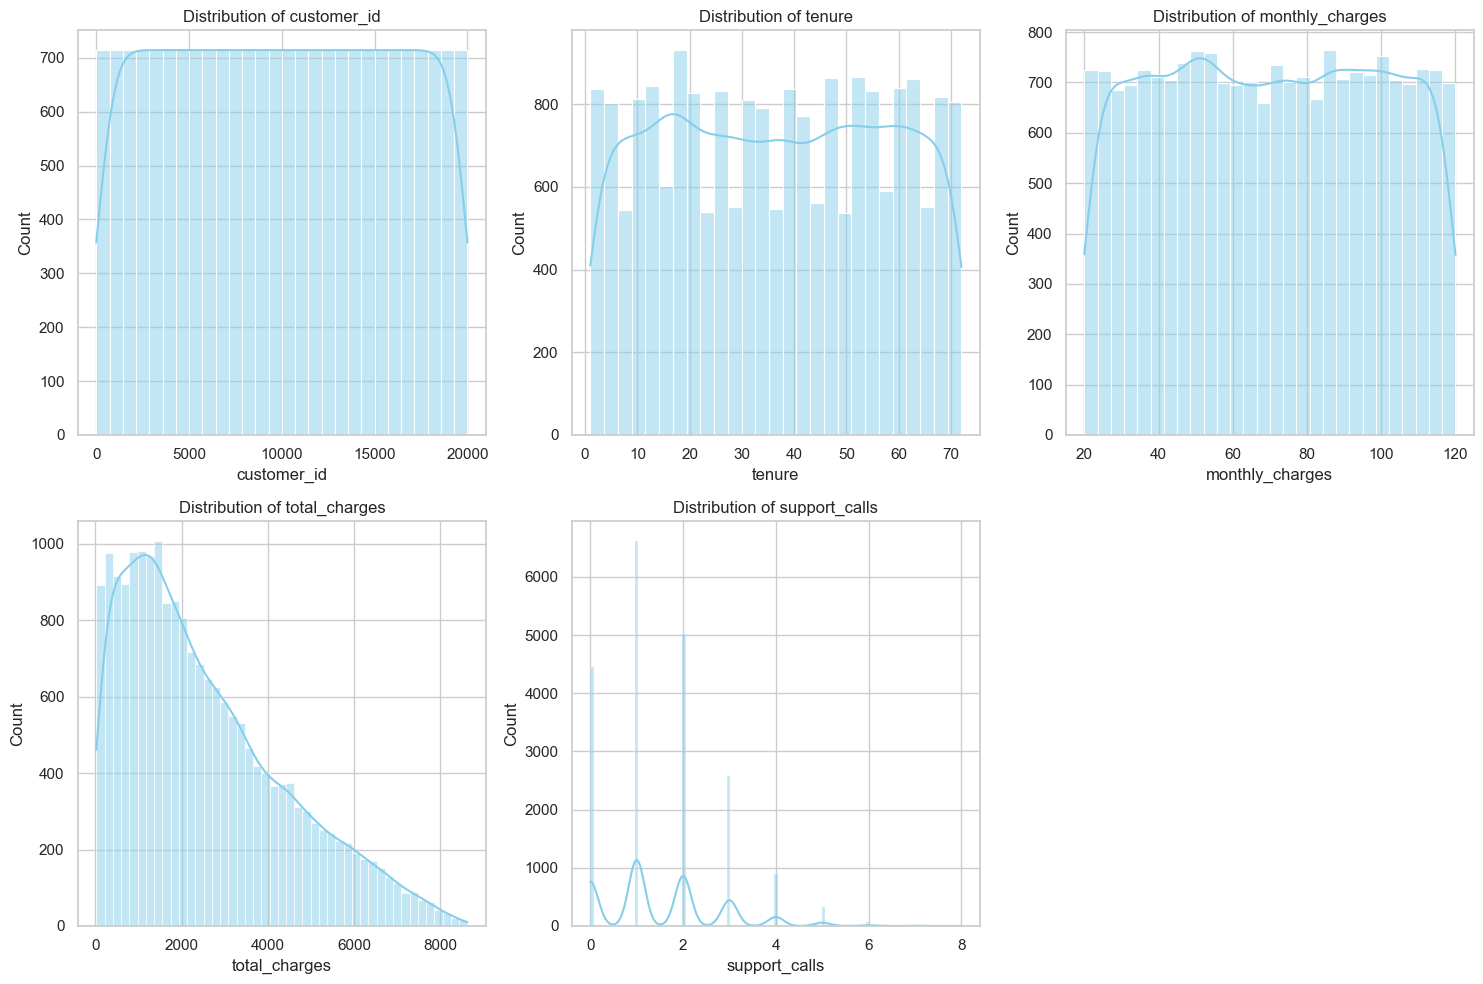

In [11]:
# Exploratory Data Analysis
sns.set(style = 'whitegrid')
# Histogram for numeric feature
numeric_df = df.select_dtypes(include=[np.number])
numeric_cols = numeric_df.columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols,1):
    plt.subplot(2,3,i)
    sns.histplot(numeric_df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

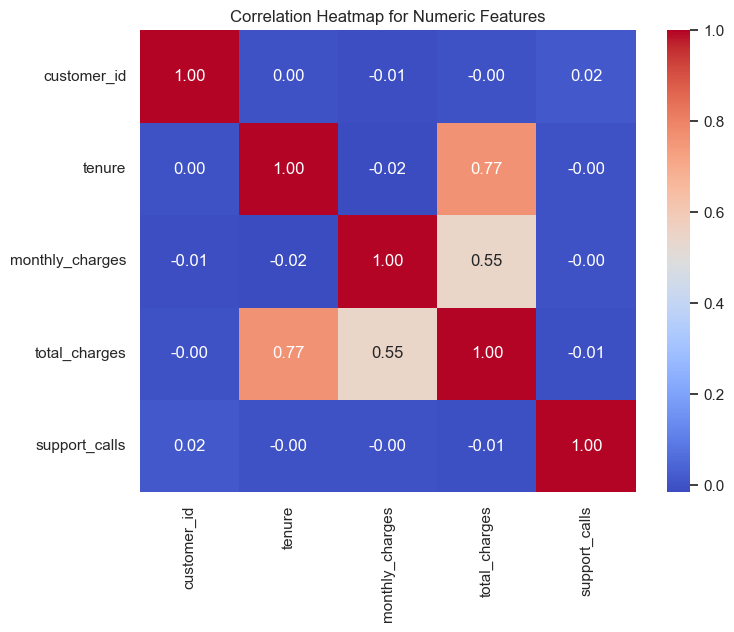

In [12]:
# Correlation Heatmap
if len(numeric_cols) >= 4:
    plt.figure(figsize = (8,6))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap for Numeric Features')
    plt.show()


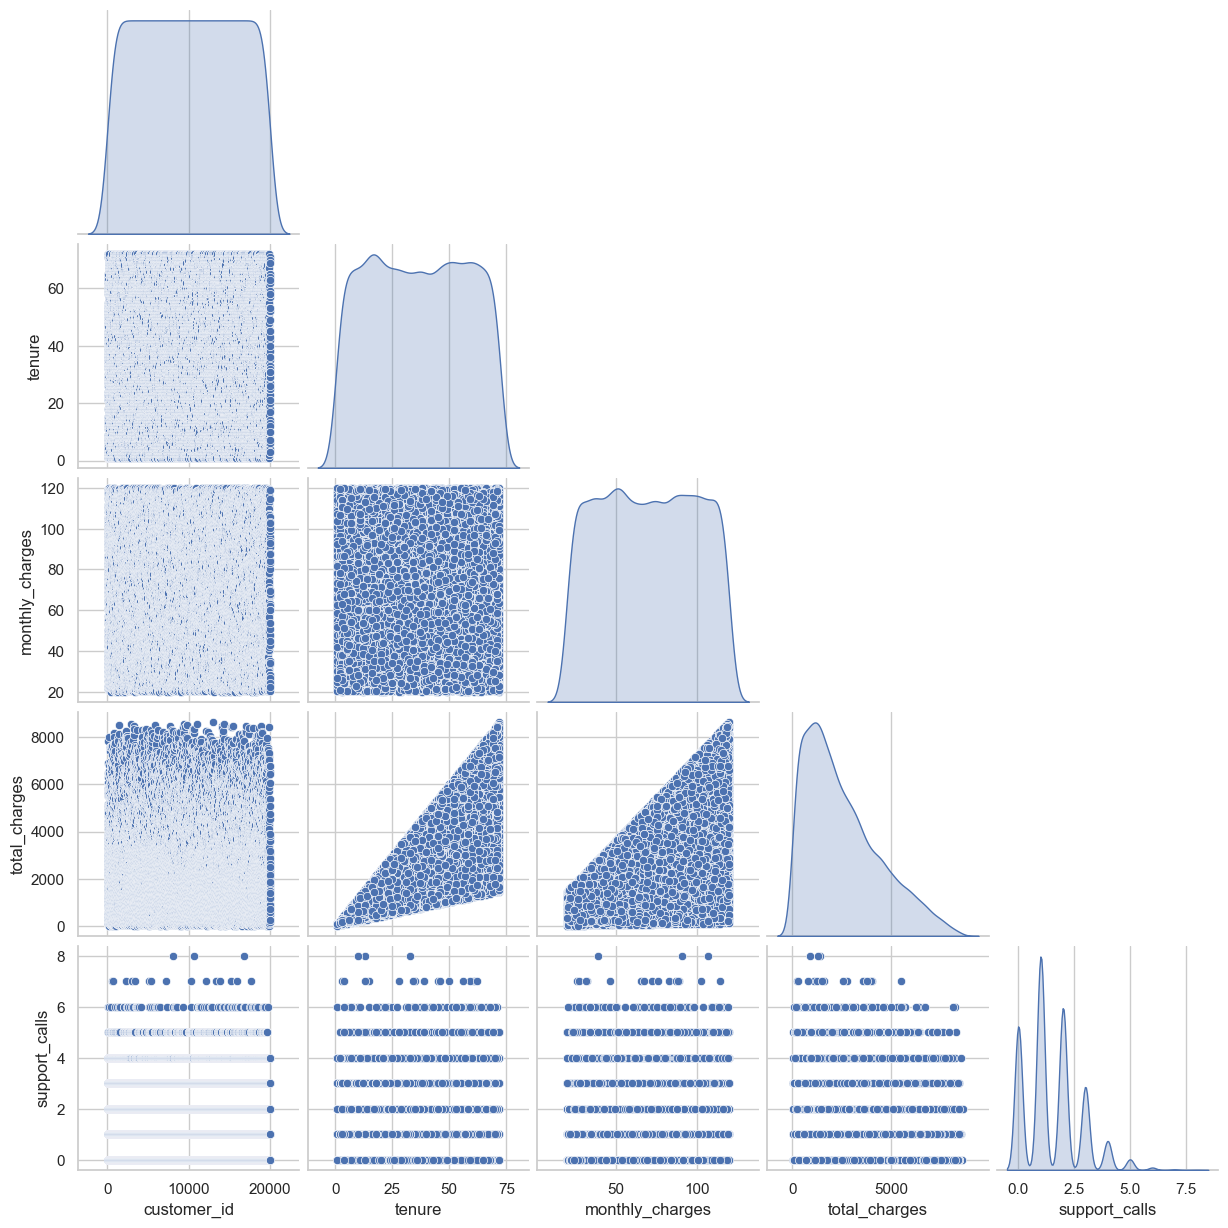

In [15]:
# Pair Plot of numeric features
sns.pairplot(numeric_df, corner = True , diag_kind = 'kde')
plt.show()

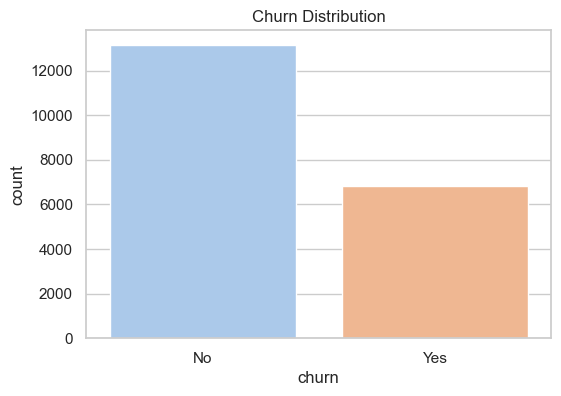

In [16]:
# Pie Chart / Countplot for churn distribution
plt.figure(figsize=(6,4))
sns.countplot(x='churn', data=df, palette='pastel')
plt.title('Churn Distribution')
plt.show()

In [19]:
df.head(3)

,customer_id,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
0,1,52,54.20,2818.40,Month-to-month,Credit,DSL,No,Yes,1,No
1,2,15,35.28,529.20,Month-to-month,Debit,DSL,No,No,2,No
2,3,72,78.24,5633.28,Month-to-month,Debit,DSL,No,No,0,No


<function matplotlib.pyplot.show(close=None, block=None)>

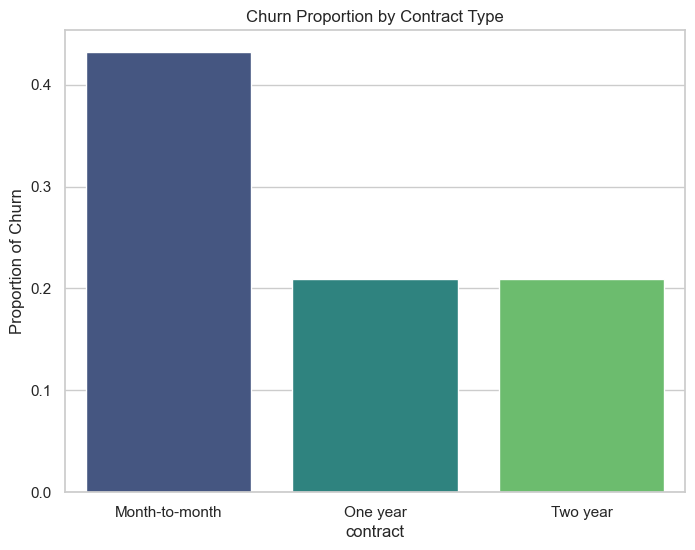

In [21]:
# Grouped Bar Plot: contract vs churn
plt.figure(figsize=(8,6))
sns.barplot(data=df, x='contract', y=df.groupby('contract')['churn'].transform(lambda x: (x=='Yes').mean()), palette='viridis')
plt.ylabel('Proportion of Churn')
plt.title('Churn Proportion by Contract Type')
plt.show

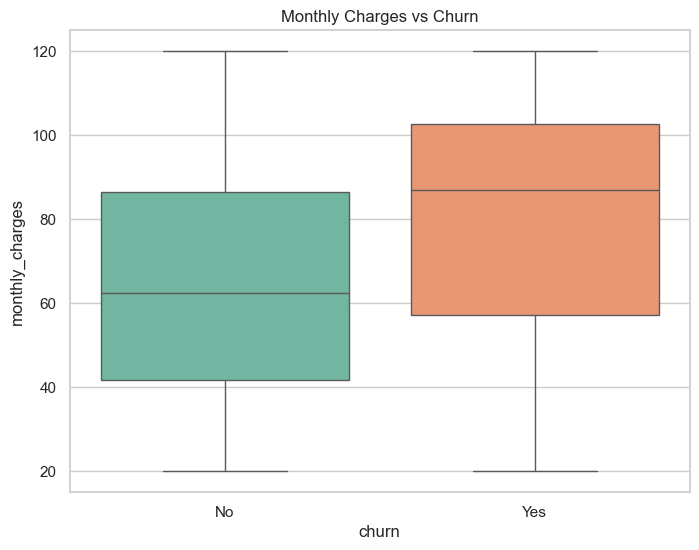

In [23]:
# Box Plot: monthly_charges vs churn
plt.figure(figsize=(8,6))
sns.boxplot(x = 'churn', y='monthly_charges', data=df, palette='Set2')
plt.title('Monthly Charges vs Churn')
plt.show()

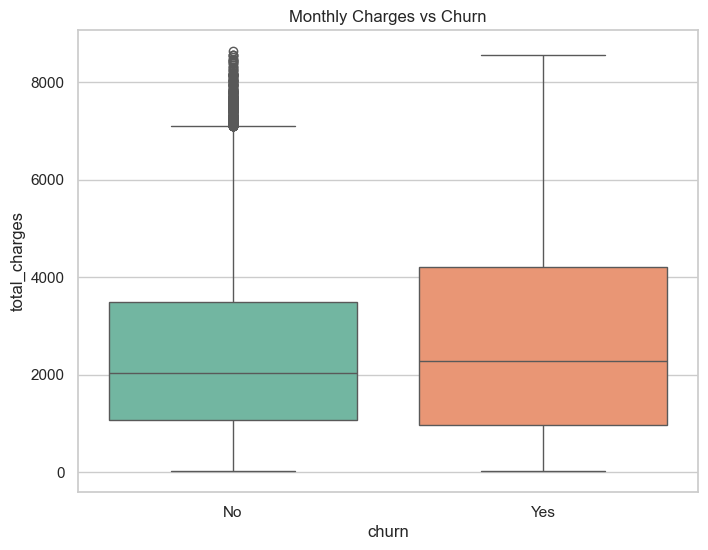

In [25]:
plt.figure(figsize=(8,6))
sns.boxplot(x = 'churn', y='total_charges', data=df, palette='Set2')
plt.title('Monthly Charges vs Churn')
plt.show()

In [27]:
# Data Preprocessing for Modeling
# Encode categorical variables using one-hot encoding
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
# Excllude 'churn' from features as it is the target
categorical_cols = [col for col in categorical_cols if col not in ['churn']]

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [29]:
df.head()

,customer_id,tenure,monthly_charges,total_charges,contract,payment_method,internet_service,tech_support,online_security,support_calls,churn
0,1,52,54.20,2818.40,Month-to-month,Credit,DSL,No,Yes,1,No
1,2,15,35.28,529.20,Month-to-month,Debit,DSL,No,No,2,No
2,3,72,78.24,5633.28,Month-to-month,Debit,DSL,No,No,0,No
3,4,61,80.24,4894.64,One year,Cash,Fiber,Yes,Yes,0,No
4,5,21,39.38,826.98,Month-to-month,UPI,Fiber,No,No,4,Yes


In [31]:
# Encode target variable: churn
df_encoded['churn'] = df_encoded['churn'].apply(lambda x: 1 if x == 'Yes' else 0)

In [33]:
df_encoded.head()

,customer_id,tenure,monthly_charges,total_charges,support_calls,churn,contract_One year,contract_Two year,payment_method_Credit,payment_method_Debit,payment_method_UPI,internet_service_Fiber,tech_support_Yes,online_security_Yes
0,1,52,54.20,2818.40,1,0,False,False,True,False,False,False,False,True
1,2,15,35.28,529.20,2,0,False,False,False,True,False,False,False,False
2,3,72,78.24,5633.28,0,0,False,False,False,True,False,False,False,False
3,4,61,80.24,4894.64,0,0,True,False,False,False,False,True,True,True
4,5,21,39.38,826.98,4,1,False,False,False,False,True,True,False,False


In [35]:
# Drop identitfier columns if necessary
if 'customer_id' in df_encoded.columns:
    df_encoded.drop('customer_id', axis=1, inplace=True)

In [37]:
# Define features (X) and target (y)
X = df_encoded.drop('churn', axis=1)
y = df_encoded['churn']

In [39]:
df_encoded.head()

,tenure,monthly_charges,total_charges,support_calls,churn,contract_One year,contract_Two year,payment_method_Credit,payment_method_Debit,payment_method_UPI,internet_service_Fiber,tech_support_Yes,online_security_Yes
0,52,54.20,2818.40,1,0,False,False,True,False,False,False,False,True
1,15,35.28,529.20,2,0,False,False,False,True,False,False,False,False
2,72,78.24,5633.28,0,0,False,False,False,True,False,False,False,False
3,61,80.24,4894.64,0,0,True,False,False,False,False,True,True,True
4,21,39.38,826.98,4,1,False,False,False,False,True,True,False,False


In [41]:
X.head()

,tenure,monthly_charges,total_charges,support_calls,contract_One year,contract_Two year,payment_method_Credit,payment_method_Debit,payment_method_UPI,internet_service_Fiber,tech_support_Yes,online_security_Yes
0,52,54.20,2818.40,1,False,False,True,False,False,False,False,True
1,15,35.28,529.20,2,False,False,False,True,False,False,False,False
2,72,78.24,5633.28,0,False,False,False,True,False,False,False,False
3,61,80.24,4894.64,0,True,False,False,False,False,True,True,True
4,21,39.38,826.98,4,False,False,False,False,True,True,False,False


In [43]:
# For our machine learning model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
plt.switch_backend('Agg')


In [46]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



In [50]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [54]:
# Predict on test data
y_pred = rf_model.predict(X_test)

In [64]:
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy of the Random Forest model: {accuracy:.2f}')

Accuracy of the Random Forest model: 0.84
